In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Dataset\Road.csv"
)

df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
df["Time"].head(20)

0     17:02:00
1     17:02:00
2     17:02:00
3      1:06:00
4      1:06:00
5     14:15:00
6     17:30:00
7     17:20:00
8     17:20:00
9     17:20:00
10    14:40:00
11    14:40:00
12    17:45:00
13    17:45:00
14    17:45:00
15    22:45:00
16    22:45:00
17    22:45:00
18    22:45:00
19     8:20:00
Name: Time, dtype: object

In [4]:
df["Time"].dtype

dtype('O')

In [5]:
df["Time"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S"
)

In [6]:
df["Hour"] = df["Time"].dt.hour

In [7]:
df[["Time", "Hour"]].head()

,Time,Hour
0,1900-01-01 17:02:00,17
1,1900-01-01 17:02:00,17
2,1900-01-01 17:02:00,17
3,1900-01-01 01:06:00,1
4,1900-01-01 01:06:00,1


In [8]:
def get_time_period(hour):

    if 5 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 17:
        return "Afternoon"

    elif 17 <= hour < 21:
        return "Evening"

    else:
        return "Night"

In [9]:
df["Time_Period"] = df["Hour"].apply(
    get_time_period
)

In [10]:
df["Time_Period"].value_counts()

Time_Period
Afternoon    3897
Evening      3496
Morning      3312
Night        1611
Name: count, dtype: int64

In [11]:
time_counts = df["Time_Period"].value_counts()

time_counts

Time_Period
Afternoon    3897
Evening      3496
Morning      3312
Night        1611
Name: count, dtype: int64

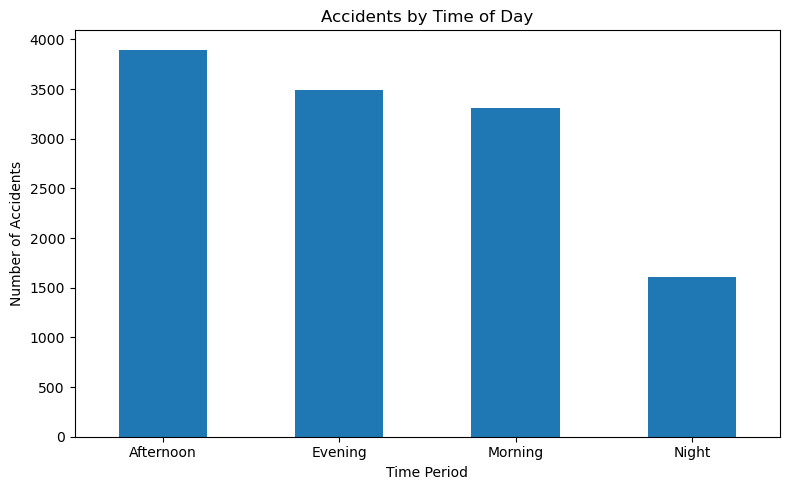

In [12]:
plt.figure(figsize=(8, 5))

time_counts.plot(kind="bar")

plt.title("Accidents by Time of Day")
plt.xlabel("Time Period")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [13]:
time_severity = pd.crosstab(
    df["Time_Period"],
    df["Accident_severity"]
)

time_severity

Accident_severity,Fatal injury,Serious Injury,Slight Injury
Time_Period,,,
Afternoon,39,535,3323
Evening,48,492,2956
Morning,25,447,2840
Night,46,269,1296


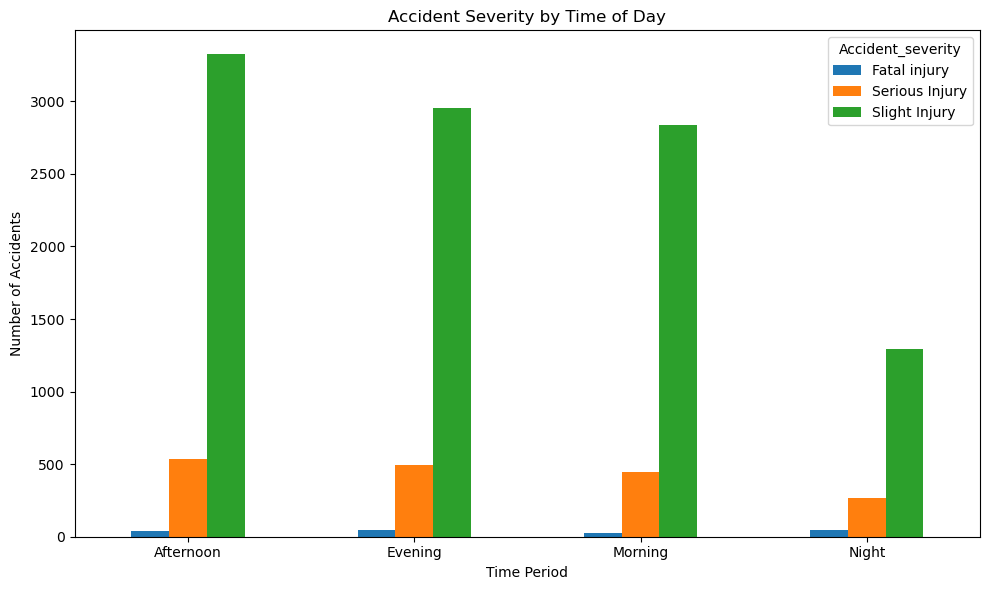

In [14]:
time_severity.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Accident Severity by Time of Day")
plt.xlabel("Time Period")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

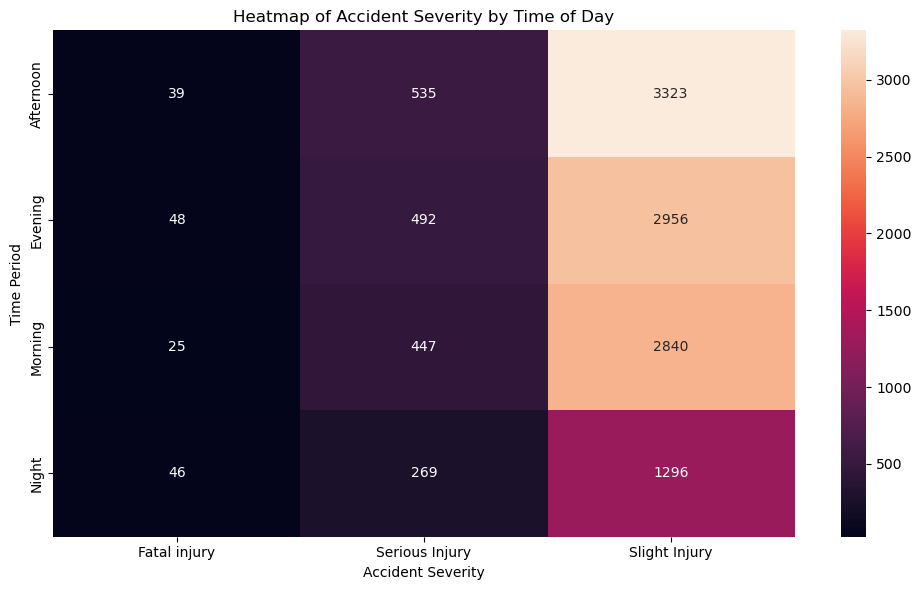

In [15]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    time_severity,
    annot=True,
    fmt="d"
)

plt.title("Heatmap of Accident Severity by Time of Day")
plt.xlabel("Accident Severity")
plt.ylabel("Time Period")

plt.tight_layout()
plt.show()

In [16]:
hourly_accidents = df["Hour"].value_counts().sort_index()

hourly_accidents

Hour
0      206
1      134
2       84
3       84
4       91
5       76
6      214
7      532
8      828
9      559
10     500
11     603
12     691
13     772
14     639
15     874
16     921
17    1228
18     956
19     708
20     604
21     401
22     402
23     209
Name: count, dtype: int64

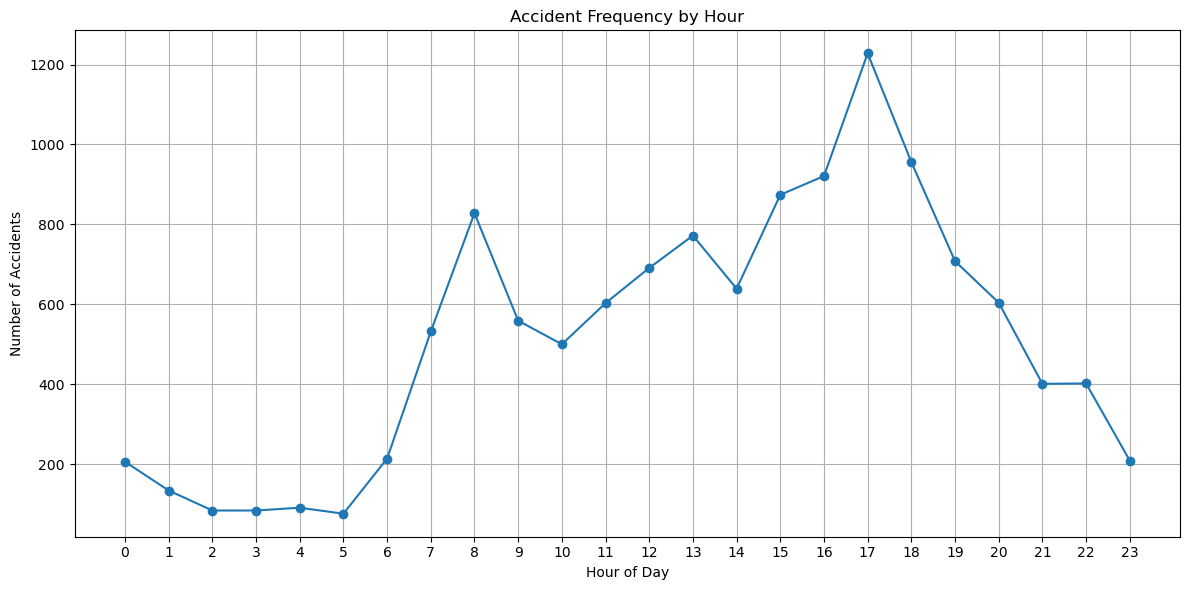

In [17]:
plt.figure(figsize=(12, 6))

hourly_accidents.plot(kind="line", marker="o")

plt.title("Accident Frequency by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Accidents")
plt.xticks(range(0, 24))

plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
time_severity.to_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Report\time_period_severity_analysis.csv"
)

In [19]:
hourly_accidents.to_csv(
    r"C:\Users\jidny\OneDrive\Documents\Hiresnix_Internship\Project_1_Accident_Severity_Predictor\Report\hourly_accident_analysis.csv"
)